In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [ ]:
!kaggle datasets download -d smaranjitghose/corn-or-maize-leaf-disease-dataset

100% 160M/161M [00:00<00:00, 227MB/s]
100% 161M/161M [00:00<00:00, 189MB/s]


['Common_Rust', 'Healthy', 'Gray_Leaf_Spot', 'Blight']
Data Had been successfully Splited into Train and Test :/content/SPLITED_DATA 
Found 3348 images belonging to 4 classes.
Found 840 images belonging to 4 classes.
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 127, 127, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 62, 62, 64)        0         
 g2D)                                                            
                                     

<ipython-input-19-1a987a562294>:175: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  predictions = model1.predict_generator(validation_generator, steps=num_samples)


Confusion Matrix:
[[68 74 25 63]
 [95 80 21 66]
 [41 32  8 34]
 [82 66 14 71]]


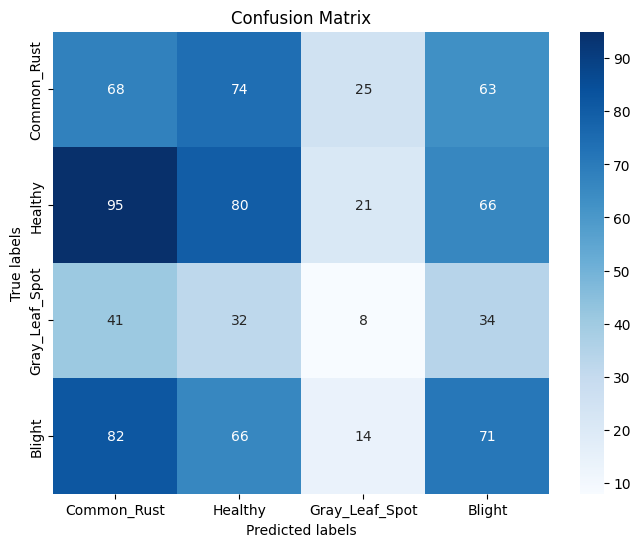

In [ ]:

import zipfile
zip_ref=zipfile.ZipFile(r'/content/corn-or-maize-leaf-disease-dataset.zip')
zip_ref.extractall('/content')
zip_ref.close()
import shutil
from sklearn.model_selection import train_test_split
import os
import cv2
def splitting_Data(dataset_root,root):

    classes = os.listdir(dataset_root)
    print(classes)
    test_size = 0.2
    train_root = os.path.join(root, "train")
    test_root = os.path.join(root, "test")
    if not os.path.exists(train_root):
        os.makedirs(train_root)
    if not os.path.exists(test_root):
        os.makedirs(test_root)
    for class_name in classes:
        class_path = os.path.join(dataset_root, class_name)
        image_files = [file for file in os.listdir(class_path) if cv2.imread(os.path.join(class_path, file)) is not None]
        train_files, test_files = train_test_split(image_files, test_size=test_size, random_state=42)
        train_class_dir = os.path.join(train_root, class_name)
        test_class_dir = os.path.join(test_root, class_name)
        if not os.path.exists(train_class_dir):
            os.makedirs(train_class_dir)
        if not os.path.exists(test_class_dir):
            os.makedirs(test_class_dir)
        for file in train_files:
            shutil.copy(os.path.join(class_path, file), os.path.join(train_class_dir, file))
        for file in test_files:
            shutil.copy(os.path.join(class_path, file), os.path.join(test_class_dir, file))
    print(f"Data Had been successfully Splited into Train and Test :{root} ")
dir_root="/content/data"
save_root="/content/SPLITED_DATA"
splitting_Data(dir_root,save_root)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_dir="/content/SPLITED_DATA/train"
validation_dir="/content/SPLITED_DATA/test"
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    shear_range=0.2,
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',
    seed=42  # Set the seed value
)

# Define a separate ImageDataGenerator for validation data (optional)
# You can adjust the augmentation parameters based on your validation data
validation_datagen = ImageDataGenerator(
    rescale=1./255
)

# Load the validation images from the directory
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical'
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Dropout
from tensorflow.keras.optimizers import Adam

def cnn_model():
    model = Sequential()

    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))

    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dense(256,activation='relu'))
    model.add(Dense(128,activation='relu'))
    model.add(Dense(4, activation='softmax'))
    return model

def modified_cnn_model():
    model = Sequential()

    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(256, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(512, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))

    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(4, activation='softmax'))

    return model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

def cnn_model3():
    model = Sequential()

    # Convolutional layers
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))

    # Flatten the output for fully connected layers
    model.add(Flatten())

    # Fully connected layers with dropout regularization
    model.add(Dense(512, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.5))
    model.add(Dense(256, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.5))

    # Output layer
    model.add(Dense(4, activation='softmax'))

    return model
model1 =cnn_model()
model1.summary()
model1.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
history1 = model1.fit(train_generator,
                              steps_per_epoch=len(train_generator),
                              epochs=10,
                              validation_data=validation_generator,
                              validation_steps=len(validation_generator))
loss,accuracy=model1.evaluate(validation_generator ,steps=validation_generator.samples//validation_generator.batch_size)
print(f"Test Loss: {loss:.4f}")
print(f"test accuracy:{accuracy:.4f}")
from sklearn.metrics import confusion_matrix
import numpy as np

# Assuming you have a trained model named 'model' and validation generator named 'validation_generator'
# 'validation_generator' should be an instance of 'ImageDataGenerator.flow_from_directory()' or similar

# Get the number of samples in the validation generator
num_samples = len(validation_generator)

# Make predictions using the model
predictions = model1.predict_generator(validation_generator, steps=num_samples)

# Get true labels from the validation generator
true_labels_onehot = np.concatenate([validation_generator[i][1] for i in range(num_samples)])

# Convert one-hot encoded true labels to class indices
true_labels = np.argmax(true_labels_onehot, axis=1)

# Convert predictions to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Compute confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)
import matplotlib.pyplot as plt
import seaborn as sns
Class_label=['Common_Rust', 'Healthy', 'Gray_Leaf_Spot', 'Blight']
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=Class_label, yticklabels=Class_label)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

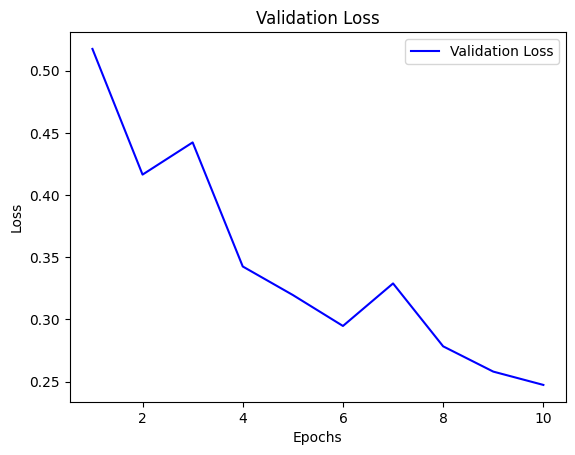

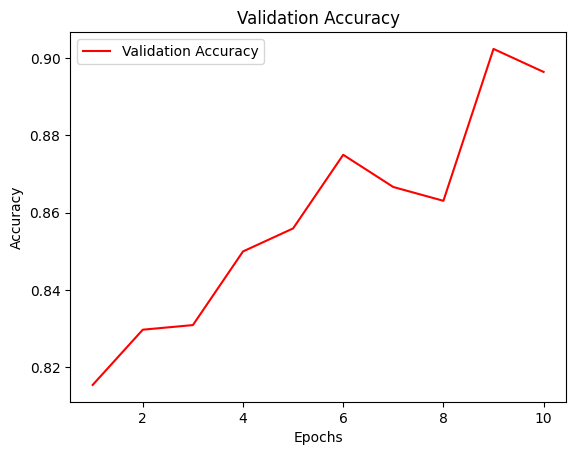

In [ ]:
import matplotlib.pyplot as plt

# Extracting the validation loss and accuracy from the history object
val_loss = history1.history['val_loss']
val_acc = history1.history['val_accuracy']

# Extracting the number of epochs
epochs = range(1, len(val_loss) + 1)

# Plotting the validation loss
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plotting the validation accuracy
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
